In [1]:
!rm -rf /kaggle/working/*

In [2]:
# ============================================================
# Imports
# ============================================================

# -------------------------
# Python Standard Library
# -------------------------
import os
import copy
import random
from collections import Counter
from itertools import cycle

# -------------------------
# Numerical Computing
# -------------------------
import numpy as np

# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# PyTorch
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, ConcatDataset, random_split

# -------------------------
# TorchVision
# -------------------------
import torchvision
from torchvision import datasets, transforms, models

# -------------------------
# Model Summary & Progress
# -------------------------
from torchinfo import summary
from tqdm.notebook import tqdm

# -------------------------
# Data Formatting
# -------------------------
from tabulate import tabulate

# -------------------------
# Scikit-learn Metrics
# -------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve,
    auc,
    classification_report,
    log_loss,
    confusion_matrix,
    top_k_accuracy_score,
    precision_recall_curve,
    average_precision_score,
)

from sklearn.preprocessing import label_binarize

import gradio as gr
from PIL import Image
%matplotlib inline

In [3]:
# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# For stricter reproducibility
torch.use_deterministic_algorithms(True)

In [4]:
# Professional plotting parameters
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1
)

plt.rcParams.update({
    # Figure
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # Font
    "font.family": "DejaVu Sans",
    "font.size": 11,

    # Title
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,

    # Labels
    "axes.labelsize": 12,
    "axes.labelweight": "bold",

    # Ticks
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.linewidth": 1.0,

    # Grid
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "grid.alpha": 0.25,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    # Legend
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.framealpha": 0.9,

    # Export
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [5]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Define paths (Adjust the dataset slug if your Kaggle URL differs)
dataset_path = "/kaggle/input/datasets/sidalikhelilcherfi/minimal-ecg-dataset"
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

# Define standard transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet standard input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load both directories
train_data = datasets.ImageFolder(root=train_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

# Combine datasets to create a fresh 80/10/10 split
full_dataset = ConcatDataset([train_data, test_data])
total_size = len(full_dataset)

# Calculate split sizes
train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size # Captures any remainder

# Perform the random split
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducibility
)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Total images: {total_size}")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")
print(f"Classes: {train_data.classes}")

Total images: 2500
Train size: 2000 | Val size: 250 | Test size: 250
Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


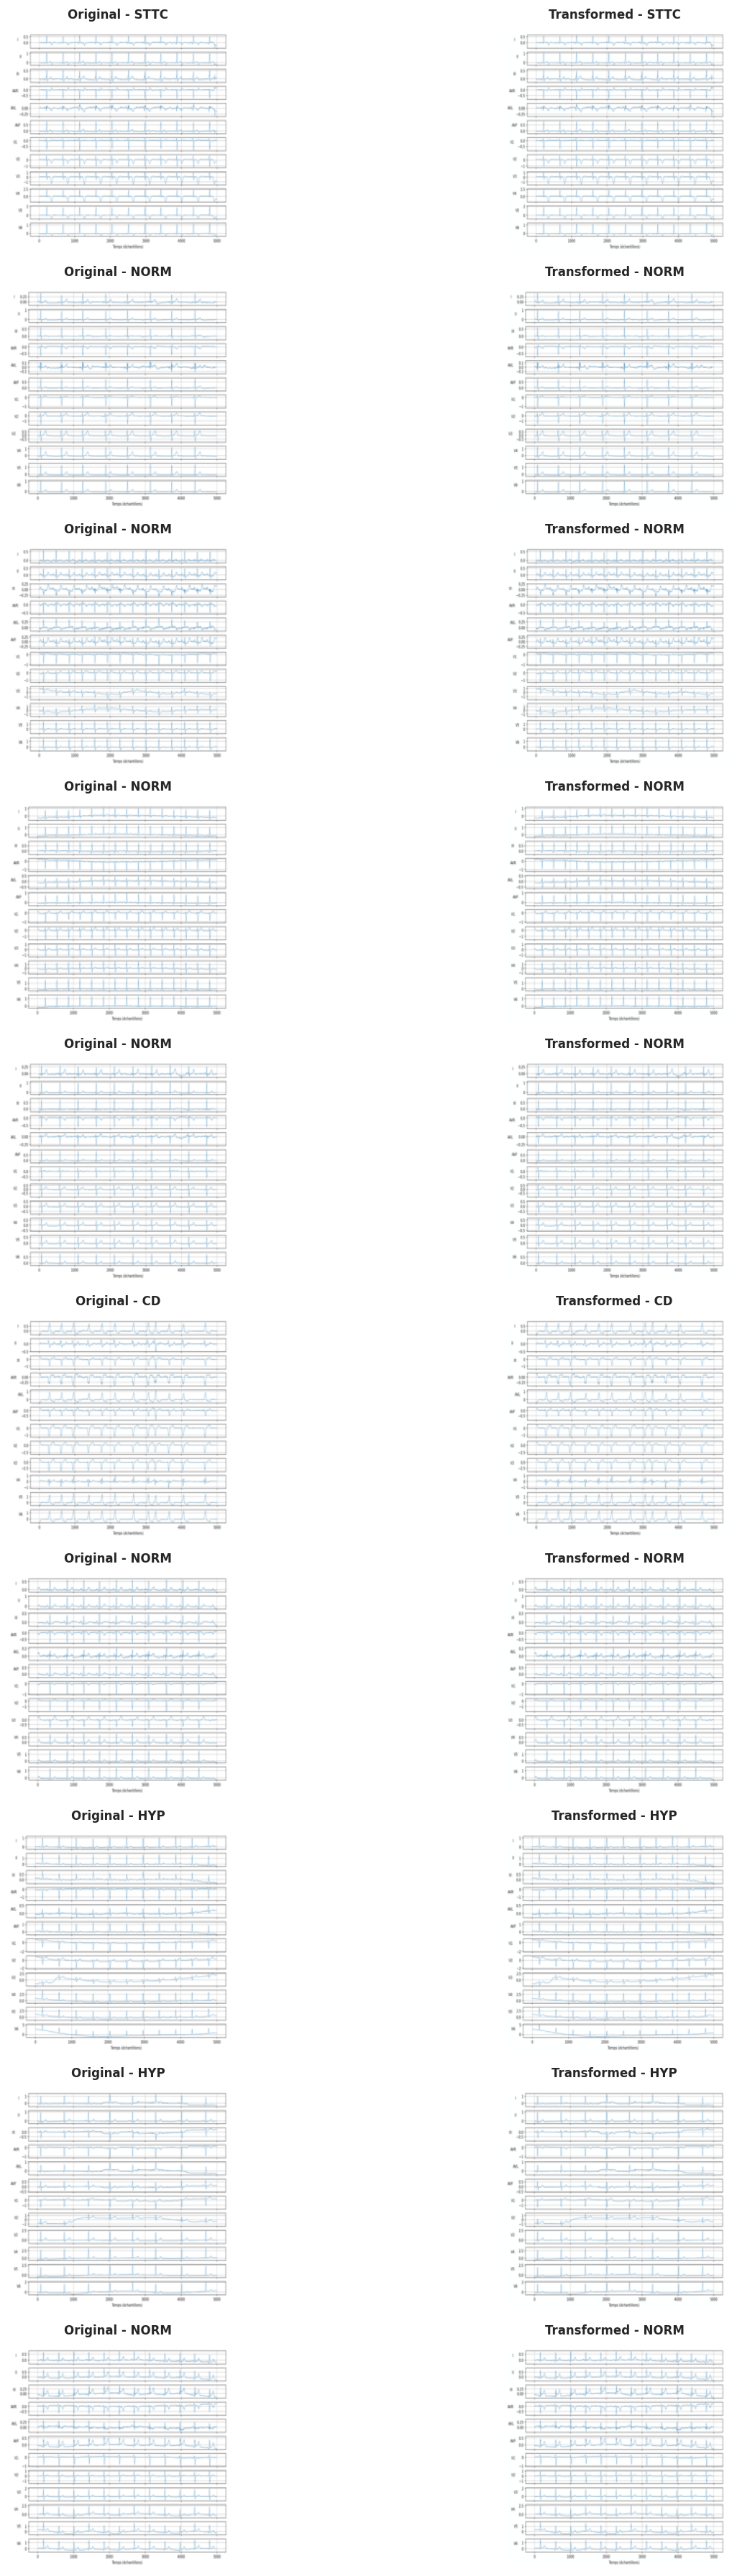

In [7]:

# Build a parallel raw (untransformed) version of the datasets
raw_transform = transforms.Compose([
    transforms.Resize((224, 224))  # resize only, no normalization, so we can display it
])

train_data_raw = datasets.ImageFolder(root=train_dir, transform=raw_transform)
test_data_raw = datasets.ImageFolder(root=test_dir, transform=raw_transform)
full_dataset_raw = ConcatDataset([train_data_raw, test_data_raw])

# Sanity check: raw and transformed datasets must be same length/order
assert len(full_dataset_raw) == len(full_dataset)

# Pick 10 random indices from the train split
sample_indices = random.sample(train_dataset.indices, 10)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(10, 2, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    # Original (raw, resized only, still PIL -> convert to array)
    orig_img, label = full_dataset_raw[idx]
    orig_img = np.array(orig_img)

    # Transformed (normalized tensor -> un-normalize for display)
    trans_img, _ = full_dataset[idx]
    trans_img = trans_img.numpy().transpose((1, 2, 0))
    trans_img = std * trans_img + mean
    trans_img = np.clip(trans_img, 0, 1)

    class_name = train_data.classes[label]

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Original - {class_name}", fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(trans_img)
    axes[row, 1].set_title(f"Transformed - {class_name}", fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_547/1866320599.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=counts, palette='viridis')


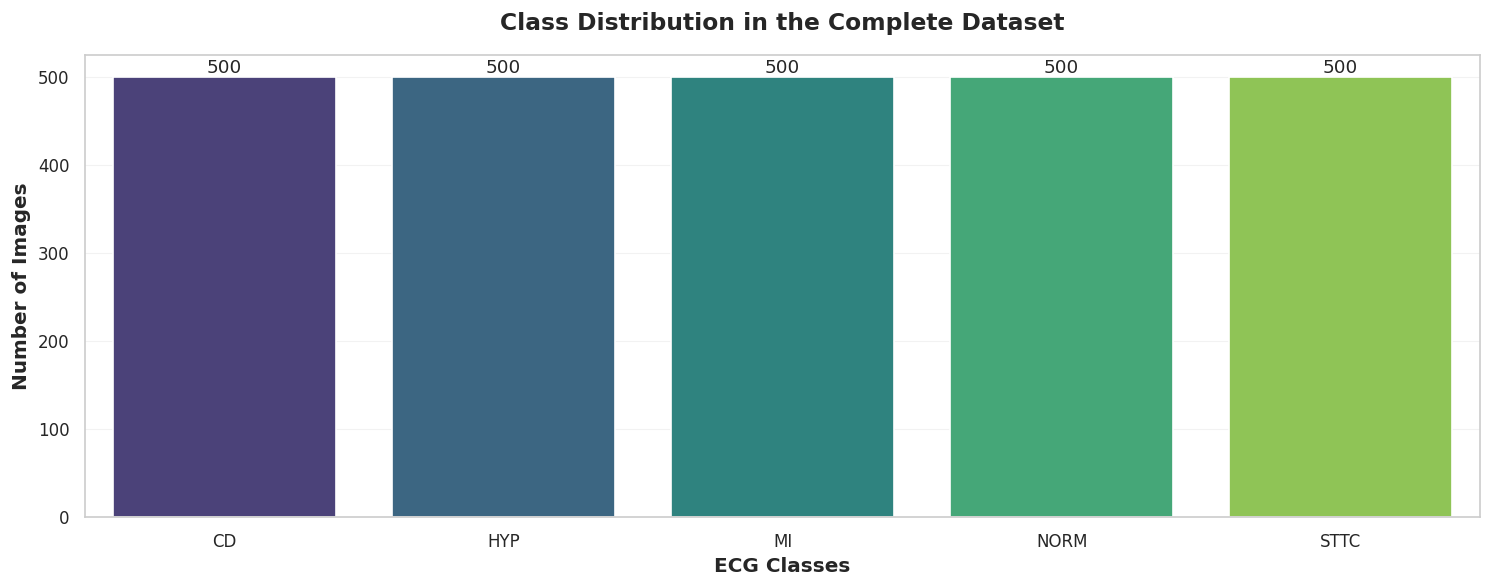

In [8]:
# Extract targets from the original datasets to calculate totals
all_targets = train_data.targets + test_data.targets
class_names = train_data.classes

# Count frequencies of each class
class_counts = Counter(all_targets)
counts = [class_counts[i] for i in range(len(class_names))]

# Plot Bar Chart
plt.figure(figsize=(15, 5))
ax = sns.barplot(x=class_names, y=counts, palette='viridis')
plt.title('Class Distribution in the Complete Dataset', fontsize=14, pad=15)
plt.xlabel('ECG Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add value labels on top of the bars
for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), str(count), ha='center', fontsize=11)

plt.show()

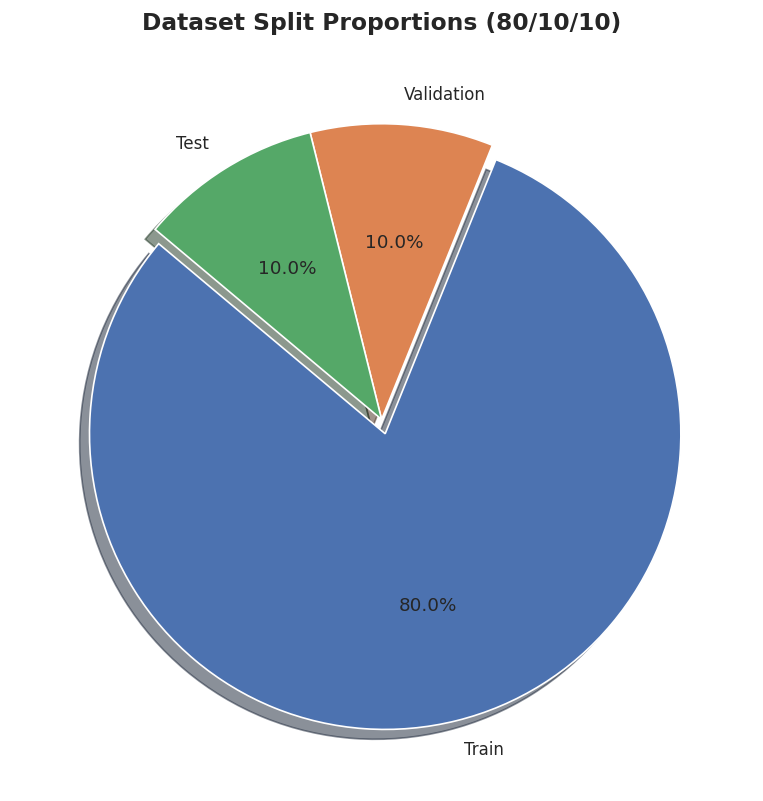

In [9]:
# Visualize Train/Val/Test split proportions
split_names = ['Train', 'Validation', 'Test']
split_sizes = [len(train_dataset), len(val_dataset), len(test_dataset)]
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 8))
plt.pie(split_sizes, labels=split_names, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=(0.05, 0, 0), shadow=True)
plt.title('Dataset Split Proportions (80/10/10)', fontsize=14)
plt.show()

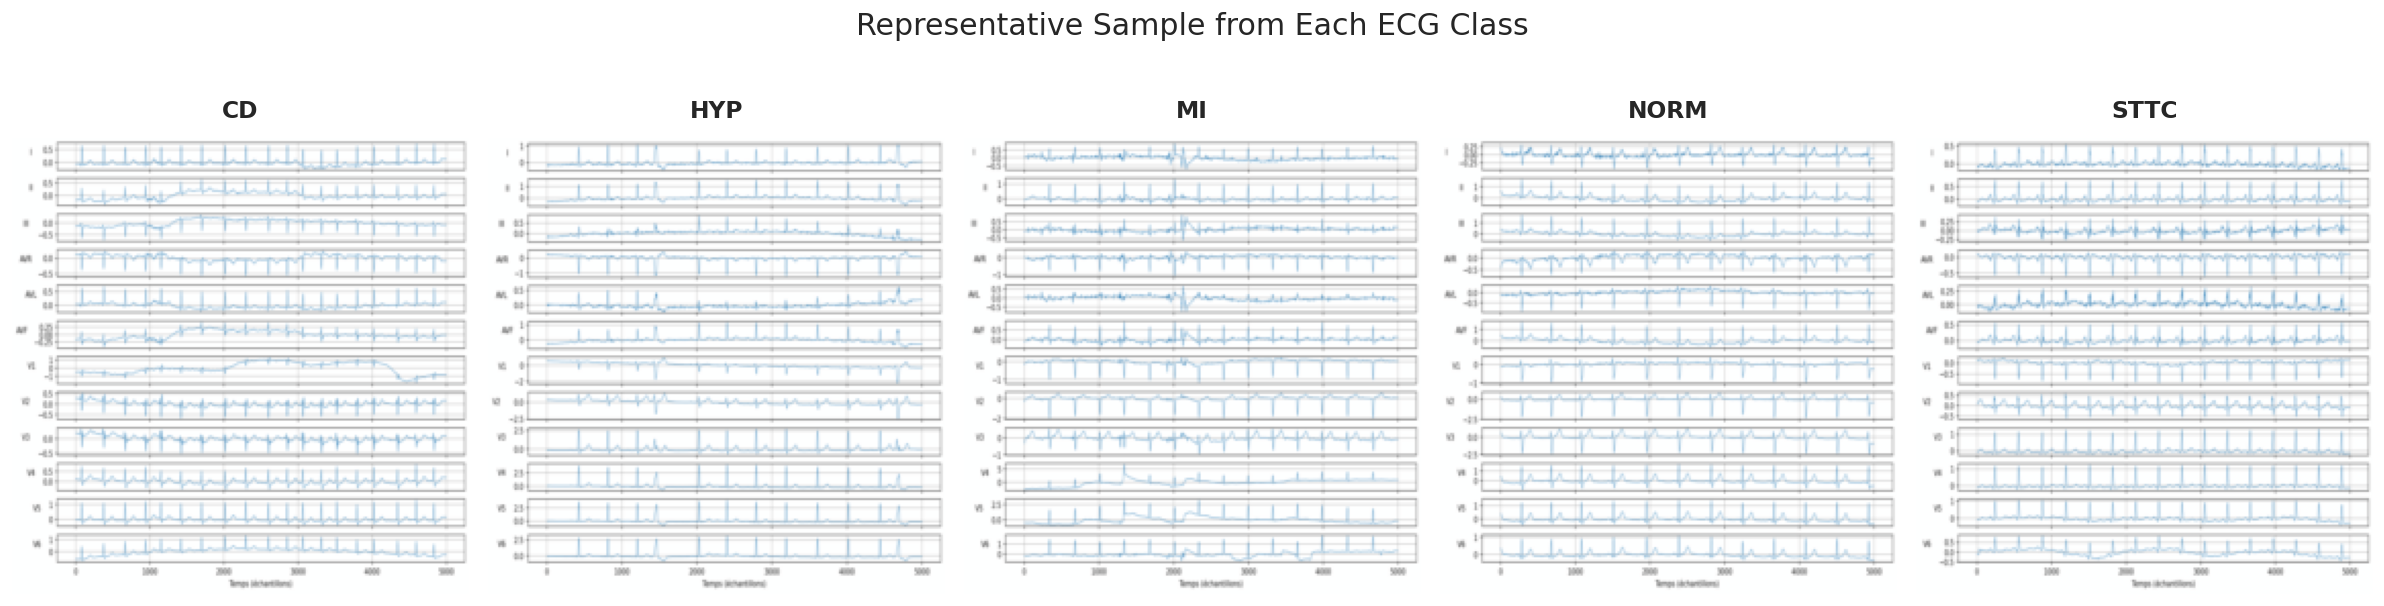

In [10]:
# Try to get labels without touching images/transforms
if hasattr(train_data, 'targets'):
    labels = np.array(train_data.targets)
elif hasattr(train_data, 'labels'):
    labels = np.array(train_data.labels)
else:
    # Fallback: build labels array once (still avoids repeated transform calls if
    # label is cheap to access, e.g. train_data.samples[i][1])
    labels = np.array([s[1] for s in train_data.samples])

# Find first index of each class using labels only
class_indices = {}
for label_idx, class_name in enumerate(class_names):
    idx = np.where(labels == label_idx)[0]
    if len(idx) > 0:
        class_indices[class_name] = idx[0]

# Now only decode/transform the images we actually need
class_images = {name: train_data[idx][0] for name, idx in class_indices.items()}

# Plot
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 5))
for ax, class_name in zip(axes, class_names):
    img = class_images[class_name].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_name, fontsize=14, fontweight='bold')
    ax.axis('off')
plt.suptitle("Representative Sample from Each ECG Class", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Batch Labels: ['HYP', 'STTC', 'STTC', 'CD', 'CD', 'MI', 'MI', 'STTC', 'CD', 'MI', 'MI', 'NORM', 'STTC', 'STTC', 'STTC', 'NORM']


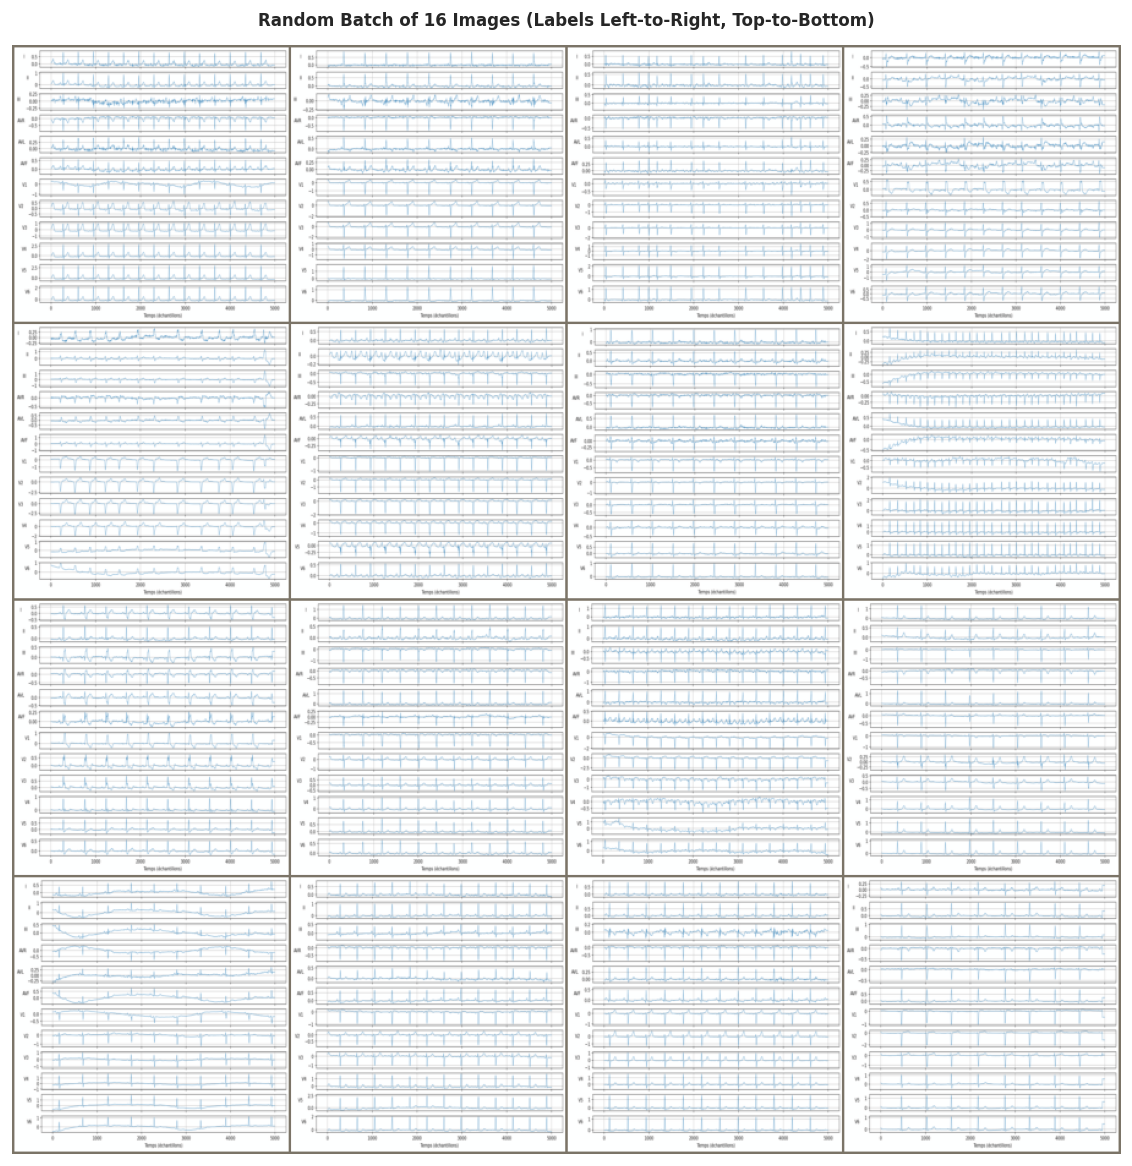

In [11]:
def imshow_unnormalized(inp, title=None):
    """Helper function to un-normalize and display a Tensor image."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Clip values to be between 0 and 1
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10)
    plt.axis('off')

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# We will display the first 16 images in the batch to avoid a massive plot
num_images_to_show = 16
out = torchvision.utils.make_grid(inputs[:num_images_to_show], nrow=4)

plt.figure(figsize=(12, 12))
# Generate titles for each image in the grid
batch_titles = [class_names[x] for x in classes[:num_images_to_show]]
imshow_unnormalized(out, title=f"Random Batch of {num_images_to_show} Images (Labels Left-to-Right, Top-to-Bottom)")
print(f"Batch Labels: {batch_titles}")
plt.show()

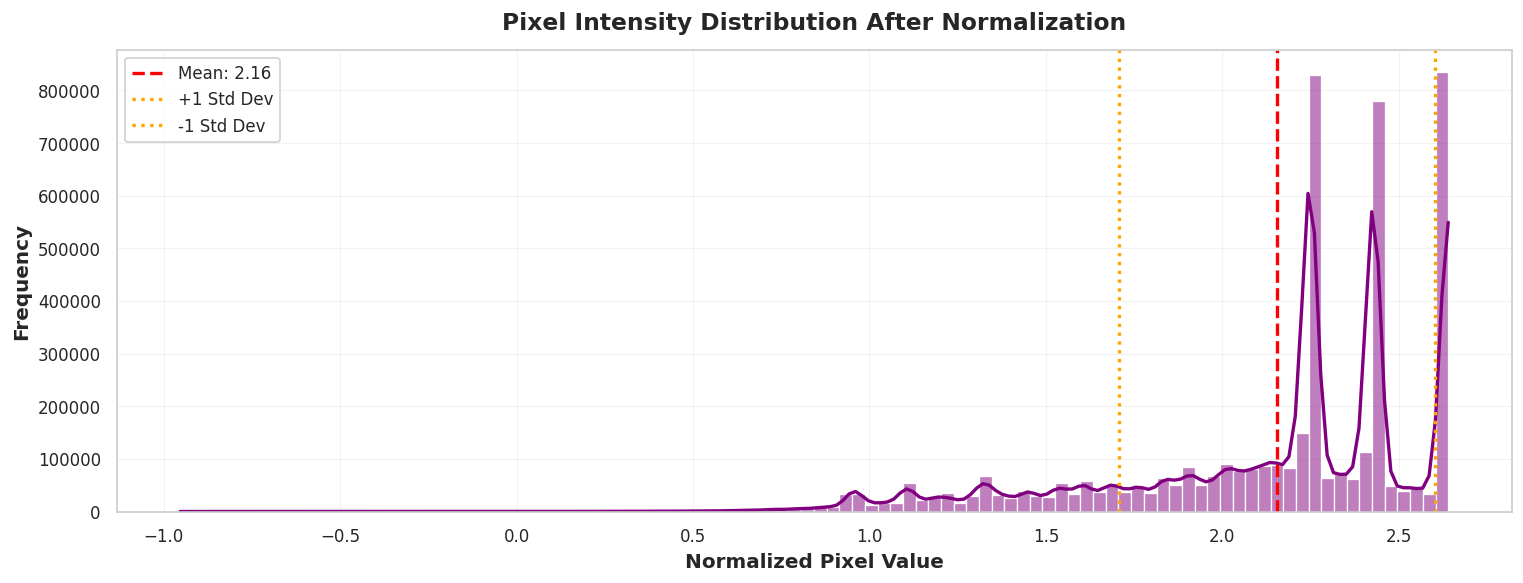

In [12]:
# Flatten a batch of images to analyze the distribution of normalized pixel values
inputs, _ = next(iter(train_loader))
pixels = inputs.numpy().flatten()

plt.figure(figsize=(15, 5))
sns.histplot(pixels, bins=100, kde=True, color='purple')
plt.title('Pixel Intensity Distribution After Normalization', fontsize=14)
plt.xlabel('Normalized Pixel Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add vertical lines for mean and standard deviation boundaries
plt.axvline(x=pixels.mean(), color='red', linestyle='--', label=f'Mean: {pixels.mean():.2f}')
plt.axvline(x=pixels.mean() + pixels.std(), color='orange', linestyle=':', label='+1 Std Dev')
plt.axvline(x=pixels.mean() - pixels.std(), color='orange', linestyle=':', label='-1 Std Dev')

plt.legend()
plt.show()

In [13]:
# Load a pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers (optional, uncomment if you only want to train the classifier head)
# for param in model.parameters():
#     param.requires_grad = False

# Modify the final fully connected layer for our 5 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) 

# Move model to the selected device (GPU/CPU)
model = model.to(device)

# Display the model summary
# input_size is (batch_size, channels, height, width)
print("--- Model Architecture Summary ---")
summary_str = summary(
    model, 
    input_size=(batch_size, 3, 224, 224), 
    col_names=["input_size", "output_size", "num_params", "trainable"], 
    col_width=20,
    row_settings=["var_names"]
)
print(summary_str)



--- Model Architecture Summary ---
Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 5]              --                   True
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    └─BasicBlock (0)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     36,864   

In [14]:
# 1. Define the Loss Function (Criterion)
criterion = nn.CrossEntropyLoss()

# 2. Define the Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Define the Learning Rate Scheduler
# Reduces learning rate by a factor of 0.1 if the validation loss doesn't improve for 3 epochs
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # 'min' because we want the loss to decrease
    factor=0.1,      # Factor by which the learning rate will be reduced
    patience=3,      # Number of epochs with no improvement after which LR will be reduced
         # Prints a message to the console when the LR drops
)


In [15]:
num_epochs = 50  # Increased since early stopping will catch it if it finishes early
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')  # Track best validation loss for early stopping
best_acc = 0.0                # Track best accuracy for metrics

# --- Early Stopping & Checkpoint Config ---
early_stop_patience = 5       # Epochs to wait before stopping if no improvement
epochs_no_improve = 0
checkpoint_path = '/kaggle/working/best_ecg_model.pth'

# --- NEW: Metrics Tracking for Graphs ---
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Starting Training with Early Stopping & Checkpointing (Vertical Output)...")

for epoch in range(num_epochs):
    # -----------------------
    # 1. Training Phase
    # -----------------------
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    
    for inputs, labels in train_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
        train_bar.set_postfix(loss=loss.item())
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (running_corrects.double() / len(train_loader.dataset)).item()

    # -----------------------
    # 2. Validation Phase
    # -----------------------
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            
            val_bar.set_postfix(loss=loss.item())
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = (val_running_corrects.double() / len(val_loader.dataset)).item()
    
    # --- NEW: Append Metrics for Plotting ---
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # -----------------------
    # 3. Scheduler Step
    # -----------------------
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # -----------------------
    # 4. Checkpoint & Early Stopping Logic
    # -----------------------
    status_msg = ""
    
    # Track best accuracy purely for our final printout
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc

    # Early stopping and Checkpointing are usually based on Validation Loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        
        # Save model weights in memory and to disk (Checkpoint)
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), checkpoint_path)
        status_msg = "Checkpoint Saved! 💾"
    else:
        epochs_no_improve += 1
        status_msg = f"No improve ({epochs_no_improve}/{early_stop_patience})"
        
    # -----------------------
    # 5. Print Tabulated Results (Vertical Stack)
    # -----------------------
    vertical_table = [
        ["Epoch", f"{epoch+1}/{num_epochs}"],
        ["Train Loss", f"{epoch_train_loss:.4f}"],
        ["Train Accuracy", f"{epoch_train_acc:.4f}"],
        ["Val Loss", f"{epoch_val_loss:.4f}"],
        ["Val Accuracy", f"{epoch_val_acc:.4f}"],
        ["Learning Rate", f"{current_lr:.6f}"],
        ["Status", status_msg]
    ]
    
    print(f"\n--- Epoch {epoch+1} Summary ---")
    print(tabulate(vertical_table, tablefmt="heavy_grid"))
    print("-" * 30)

    # Break loop if early stopping is triggered
    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping triggered after {epoch + 1} epochs!")
        break

print("=" * 40)
print(f"Training Complete! Best Validation Accuracy: {best_acc:.4f}")

# Load the best weights back into the model from memory for inference/testing
model.load_state_dict(best_model_wts)
print(f"Restored best model weights from memory. (Also saved to {checkpoint_path})")

Starting Training with Early Stopping & Checkpointing (Vertical Output)...


Epoch 1/50 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


--- Epoch 1 Summary ---
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Epoch          ┃ 1/50                 ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Train Loss     ┃ 1.3159               ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Train Accuracy ┃ 0.4700               ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Val Loss       ┃ 1.4308               ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Val Accuracy   ┃ 0.3920               ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Learning Rate  ┃ 0.001000             ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃ Status         ┃ Checkpoint Saved! 💾 ┃
┗━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━┛
------------------------------


Epoch 2/50 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 12/50 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


--- Epoch 12 Summary ---
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Epoch          ┃ 12/50            ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Train Loss     ┃ 0.0796           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Train Accuracy ┃ 0.9800           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Val Loss       ┃ 1.5034           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Val Accuracy   ┃ 0.6400           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Learning Rate  ┃ 0.000010         ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Status         ┃ No improve (4/5) ┃
┗━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━┛
------------------------------


Epoch 13/50 [Train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 13/50 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


--- Epoch 13 Summary ---
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Epoch          ┃ 13/50            ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Train Loss     ┃ 0.0472           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Train Accuracy ┃ 0.9915           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Val Loss       ┃ 1.4817           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Val Accuracy   ┃ 0.6720           ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Learning Rate  ┃ 0.000010         ┃
┣━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━┫
┃ Status         ┃ No improve (5/5) ┃
┗━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━┛
------------------------------

Early stopping triggered after 13 epochs!
Training Complete! Best Validation Accuracy: 0.6800
Restored best model weights from memory. (Also saved to /kaggle/working/best_ecg_model.pth)


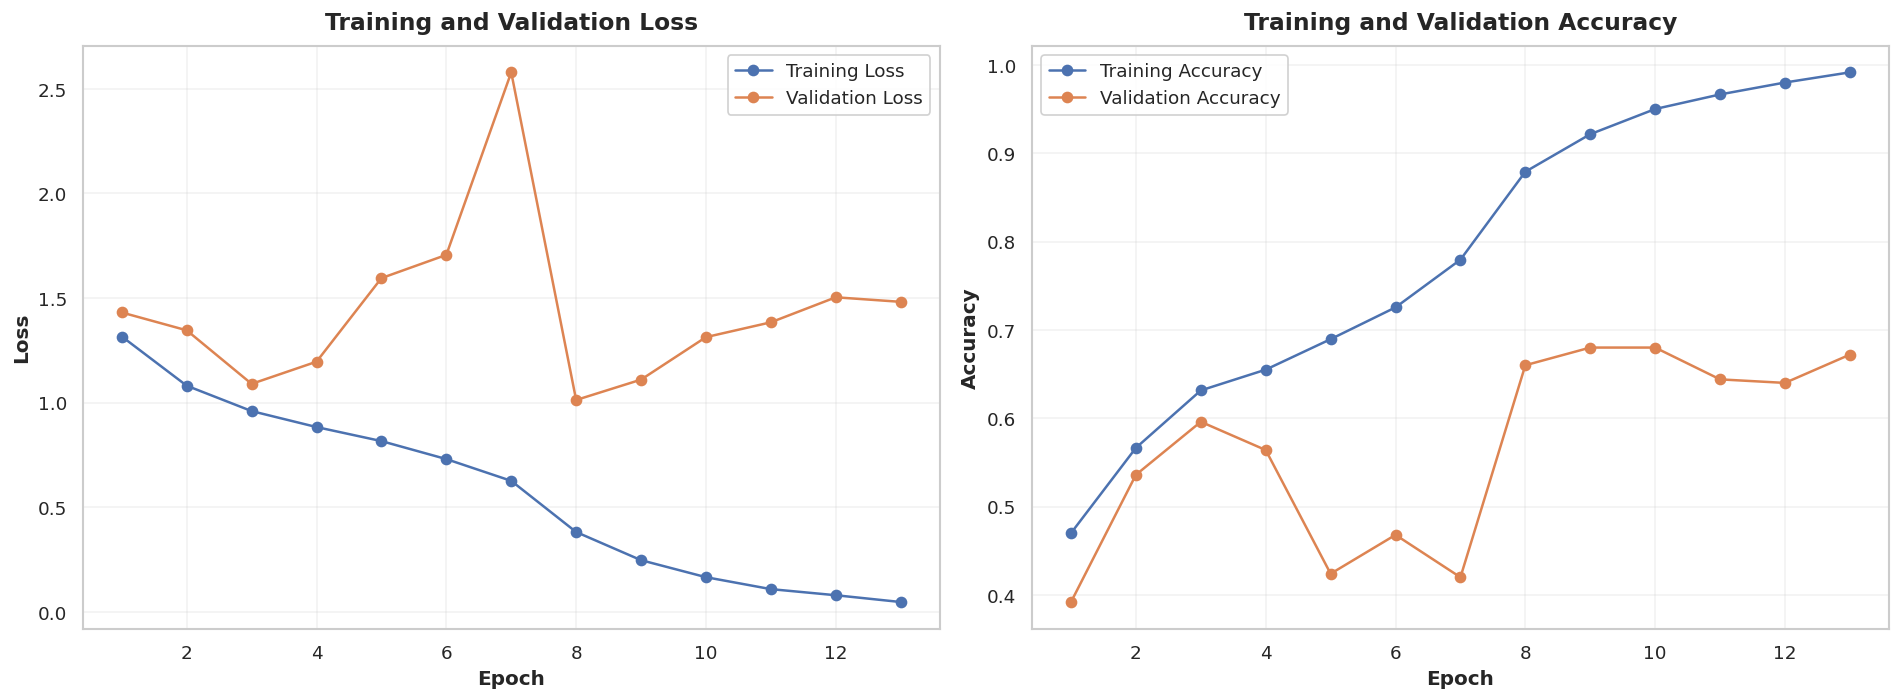

In [16]:
# Ensure the seaborn theme is applied for clean visuals
sns.set_theme(style="whitegrid")

# Create the x-axis for the epochs
epochs_range = range(1, len(train_losses) + 1)

# Set up a wider figure to hold both plots side-by-side
plt.figure(figsize=(16, 6))

# -----------------------
# Graph 1: Loss
# -----------------------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', marker='o', color='#4C72B0')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o', color='#DD8452')
plt.title('Training and Validation Loss', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)

# -----------------------
# Graph 2: Accuracy
# -----------------------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Training Accuracy', marker='o', color='#4C72B0')
plt.plot(epochs_range, val_accs, label='Validation Accuracy', marker='o', color='#DD8452')
plt.title('Training and Validation Accuracy', fontsize=14, pad=10)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

In [17]:
# Ensure the model is in evaluation mode
model.eval()

# Lists to store the results
all_preds = []
all_labels = []
all_probs = []

print("Evaluating the best model on the unseen Test Set...")

# Disable gradient calculation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Get probabilities (needed for ROC AUC)
        probs = F.softmax(outputs, dim=1)
        
        # Get class predictions
        _, preds = torch.max(outputs, 1)
        
        # Move to CPU and convert to numpy for scikit-learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert lists to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# --- Calculate Metrics ---
# Using 'macro' average calculates metrics for each label and finds their unweighted mean.
# 'ovr' stands for One-vs-Rest, which is required for multi-class ROC AUC.
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
mcc = matthews_corrcoef(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)

# --- Format and Print Results ---
metrics_table = [
    ["Accuracy", f"{acc:.4f}"],
    ["Precision (Macro)", f"{prec:.4f}"],
    ["Recall (Macro)", f"{rec:.4f}"],
    ["F1 Score (Macro)", f"{f1:.4f}"],
    ["ROC AUC (OVR, Macro)", f"{roc_auc:.4f}"],
    ["Matthews Correlation (MCC)", f"{mcc:.4f}"],
    ["Cohen's Kappa Score", f"{kappa:.4f}"]
]

print("\n--- Test Set Evaluation Metrics ---")
print(tabulate(metrics_table, headers=["Metric", "Score"], tablefmt="heavy_grid"))

Evaluating the best model on the unseen Test Set...

--- Test Set Evaluation Metrics ---
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Metric                     ┃   Score ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ Accuracy                   ┃  0.644  ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ Precision (Macro)          ┃  0.6559 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ Recall (Macro)             ┃  0.6471 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ F1 Score (Macro)           ┃  0.6471 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ ROC AUC (OVR, Macro)       ┃  0.8934 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ Matthews Correlation (MCC) ┃  0.5567 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━┫
┃ Cohen's Kappa Score        ┃  0.555  ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━┛


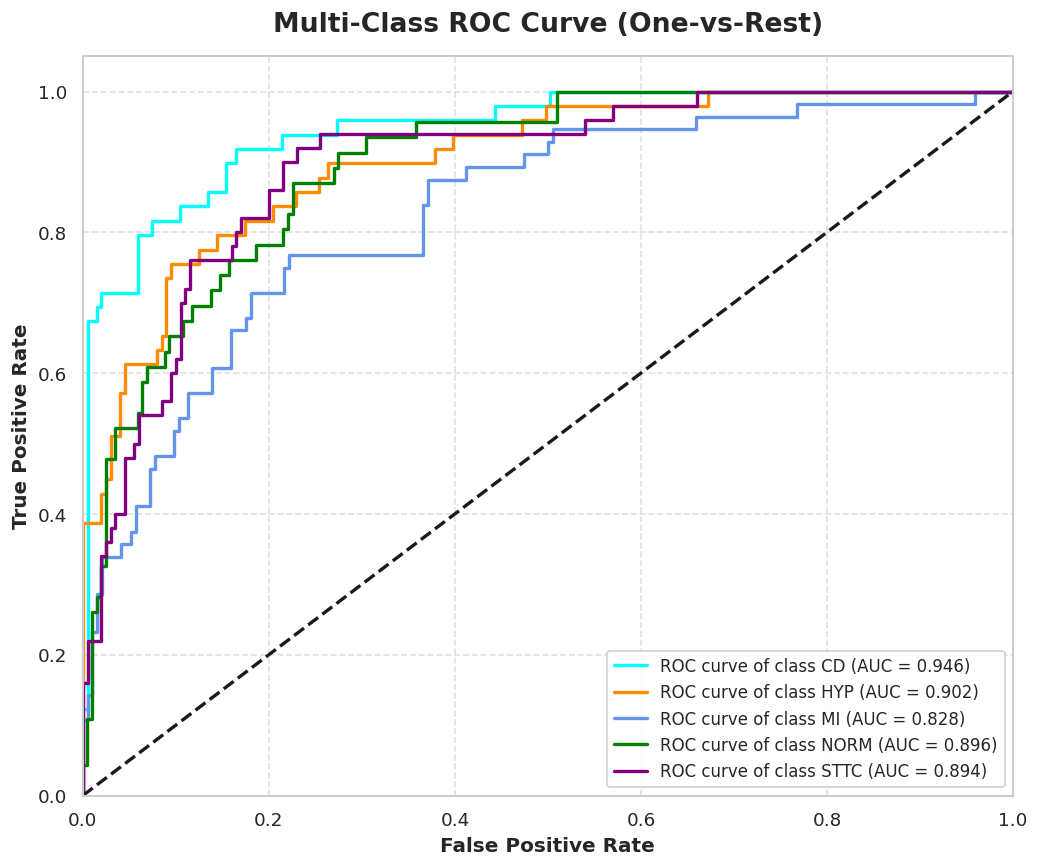

In [18]:
# Binarize the true labels for the One-vs-Rest ROC calculation
# Assuming 5 classes labeled 0, 1, 2, 3, 4
classes_idx = [0, 1, 2, 3, 4]
y_true_bin = label_binarize(all_labels, classes=classes_idx)
n_classes = y_true_bin.shape[1]

# Re-fetch class names if they aren't in memory (from your dataset)
class_names = train_data.classes

# Dictionaries to hold False Positive Rate (fpr), True Positive Rate (tpr), and Area Under Curve (auc)
fpr = dict()
tpr = dict()
roc_auc_dict = dict()

# Calculate ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])

# --- Plotting ---
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], 
        tpr[i], 
        color=color, 
        lw=2,
        label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc_dict[i]:.3f})'
    )

# Plot the diagonal line representing random guessing
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curve (One-vs-Rest)', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

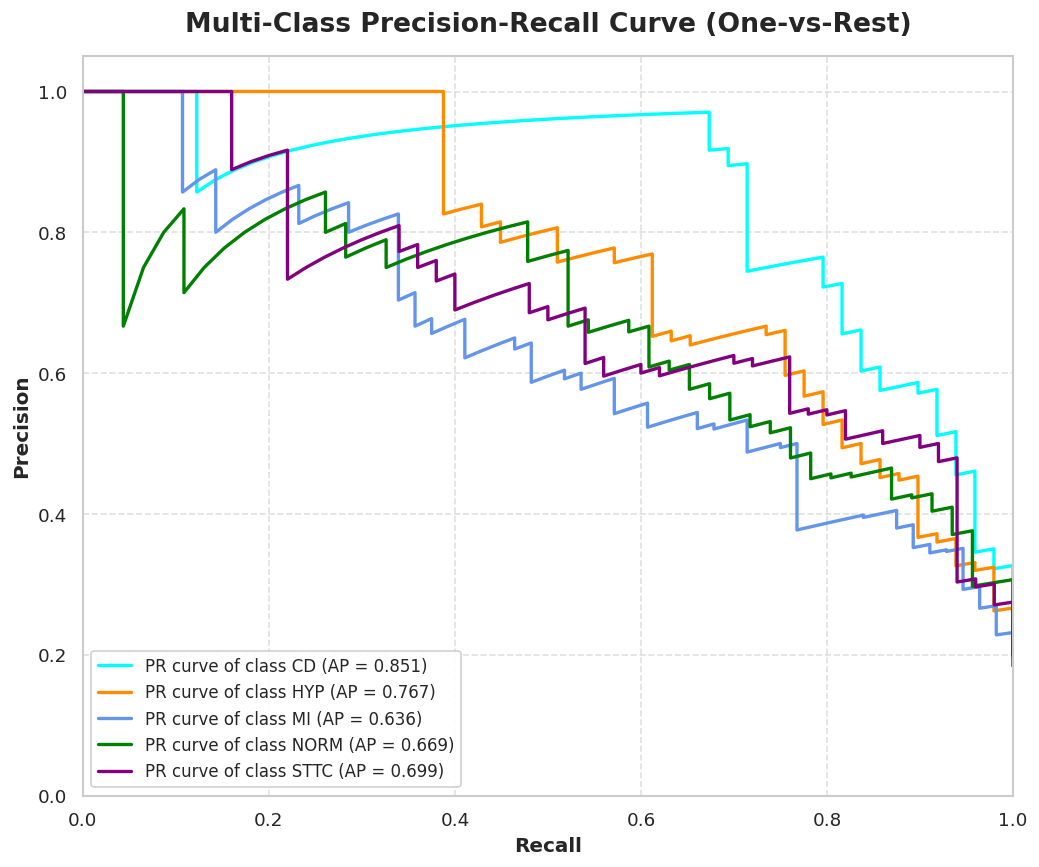

In [19]:
# Binarize the true labels for One-vs-Rest PR calculation
classes_idx = [0, 1, 2, 3, 4]
y_true_bin = label_binarize(all_labels, classes=classes_idx)
n_classes = y_true_bin.shape[1]

# Re-fetch class names if they aren't in memory
class_names = train_data.classes

# Dictionaries to hold precision, recall, and average precision (AP)
precision = dict()
recall = dict()
average_precision = dict()

# Calculate PR curve and AP for each class
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], all_probs[:, i])

# --- Plotting ---
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        recall[i], 
        precision[i], 
        color=color, 
        lw=2,
        label=f'PR curve of class {class_names[i]} (AP = {average_precision[i]:.3f})'
    )

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Multi-Class Precision-Recall Curve (One-vs-Rest)', fontsize=16, pad=15)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

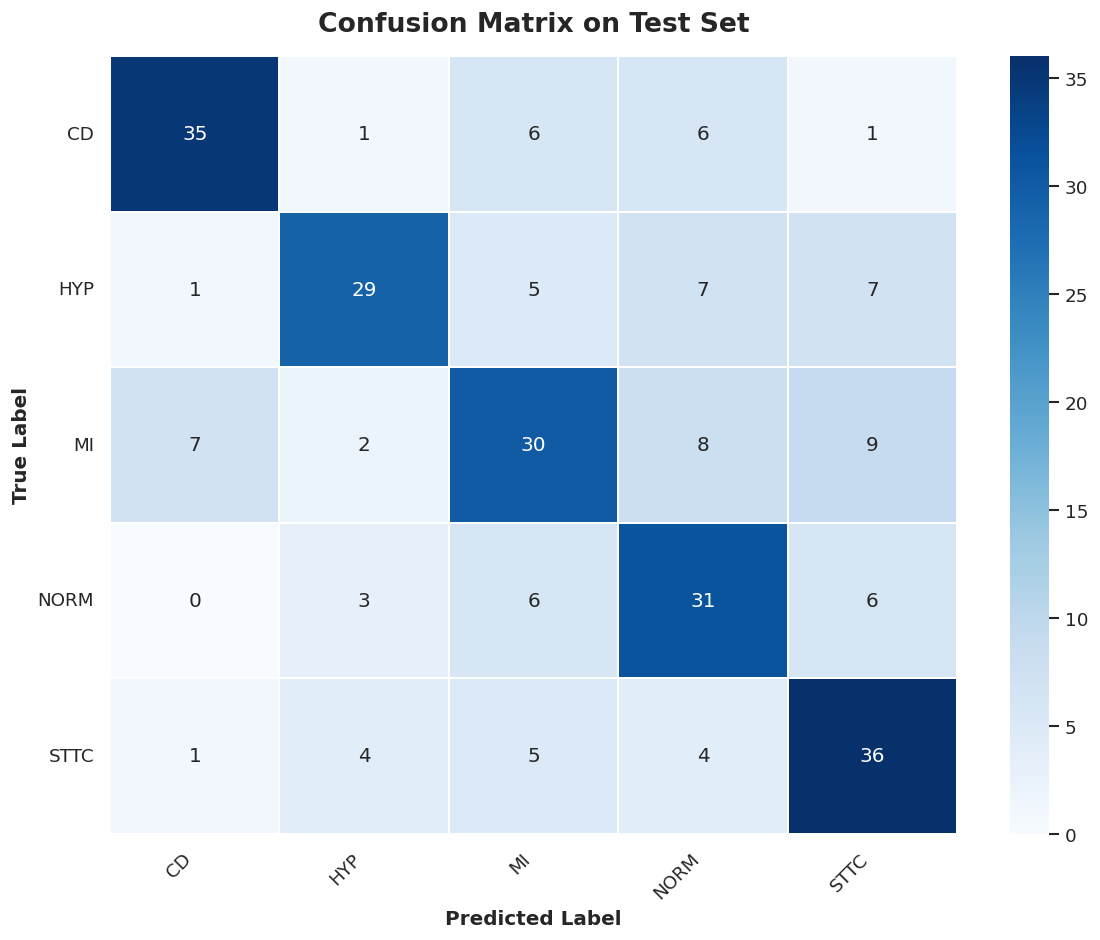

In [20]:
# Calculate the confusion matrix using true labels and predictions
cm = confusion_matrix(all_labels, all_preds)

# Re-fetch class names if they aren't in memory
class_names = train_data.classes

# --- Plotting ---
plt.figure(figsize=(10, 8))

# Use Seaborn's heatmap for a clean, readable visual
# fmt='d' ensures the numbers are formatted as integers
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    linewidths=1, 
    linecolor='white'
)

plt.title('Confusion Matrix on Test Set', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

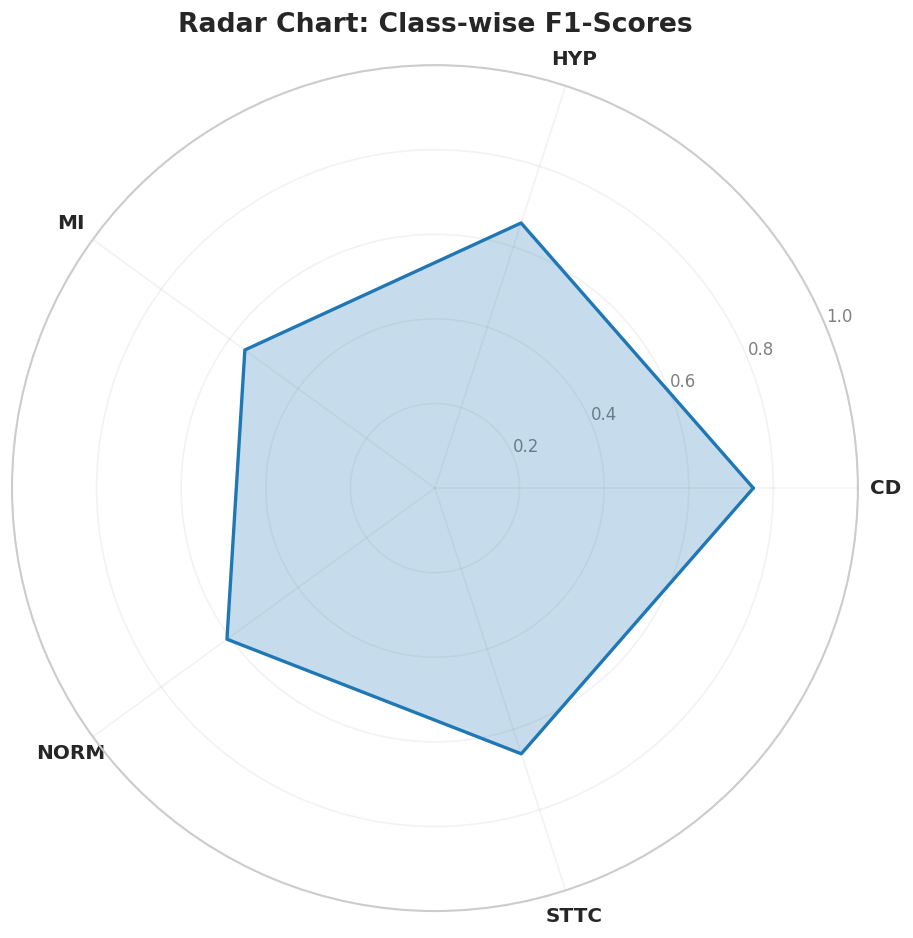

In [21]:
# Generate classification report as a dictionary to extract per-class metrics
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

# Extract F1-score for each class
class_f1_scores = [report[class_name]['f1-score'] for class_name in class_names]

# Number of variables/classes
num_vars = len(class_names)

# Compute angle for each axis in the radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The radar chart is a circle, so we need to "close the loop" by appending the first value to the end
class_f1_scores += class_f1_scores[:1]
angles += angles[:1]
radar_class_names = class_names + [class_names[0]]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw the outline and fill the area
ax.plot(angles, class_f1_scores, color='#1f77b4', linewidth=2, linestyle='solid', label='F1-Score')
ax.fill(angles, class_f1_scores, color='#1f77b4', alpha=0.25)

# Fix axis to match the 0 to 1 range of metrics
ax.set_ylim(0, 1.0)

# Set the labels for each category
plt.xticks(angles[:-1], class_names, fontsize=12, fontweight='bold')

# Configure grid and title
ax.set_rgrids([0.2, 0.4, 0.6, 0.8, 1.0], labels=['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=10)
plt.title('Radar Chart: Class-wise F1-Scores', fontsize=16, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
print("--- Detailed Classification Report ---")
print("This report shows Precision, Recall, F1-Score, and Support (image count) for each individual class.\n")

# Generate the textual classification report
report_text = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names, 
    digits=4 # Show 4 decimal places for precision
)

print(report_text)

--- Detailed Classification Report ---
This report shows Precision, Recall, F1-Score, and Support (image count) for each individual class.

              precision    recall  f1-score   support

          CD     0.7955    0.7143    0.7527        49
         HYP     0.7436    0.5918    0.6591        49
          MI     0.5769    0.5357    0.5556        56
        NORM     0.5536    0.6739    0.6078        46
        STTC     0.6102    0.7200    0.6606        50

    accuracy                         0.6440       250
   macro avg     0.6559    0.6471    0.6471       250
weighted avg     0.6548    0.6440    0.6451       250



In [23]:
# Calculate the Log Loss using the true labels and the predicted softmax probabilities
# log_loss is the scikit-learn equivalent of PyTorch's CrossEntropyLoss
test_log_loss = log_loss(all_labels, all_probs)

print("--- Test Loss (Log Loss) ---")
print(f"Test Log Loss: {test_log_loss:.4f}")

--- Test Loss (Log Loss) ---
Test Log Loss: 1.0385


In [24]:

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Initialize a list to hold the formatted row data for our table
per_class_metrics = []

# Iterate through each class to calculate its specific metrics
for i, class_name in enumerate(class_names):
    # True Positives: The diagonal element for this class
    TP = cm[i, i]
    
    # False Positives: The sum of the column for this class, minus TP
    FP = cm[:, i].sum() - TP
    
    # False Negatives: The sum of the row for this class, minus TP
    FN = cm[i, :].sum() - TP
    
    # True Negatives: Total samples minus (TP + FP + FN)
    TN = cm.sum() - (TP + FP + FN)
    
    # Calculate Metrics (adding a small epsilon 1e-7 to prevent division by zero)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-7)
    recall = TP / (TP + FN + 1e-7)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
    
    # Append to our table data
    per_class_metrics.append([
        class_name,
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}"
    ])

# Define the headers
headers = ["Class", "Accuracy", "Precision", "Recall", "F1-Score"]

print("--- Per-Class Evaluation Metrics ---")
print(tabulate(per_class_metrics, headers=headers, tablefmt="heavy_grid"))

--- Per-Class Evaluation Metrics ---
┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Class   ┃   Accuracy ┃   Precision ┃   Recall ┃   F1-Score ┃
┣━━━━━━━━━╋━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ CD      ┃      0.908 ┃      0.7955 ┃   0.7143 ┃     0.7527 ┃
┣━━━━━━━━━╋━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ HYP     ┃      0.88  ┃      0.7436 ┃   0.5918 ┃     0.6591 ┃
┣━━━━━━━━━╋━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ MI      ┃      0.808 ┃      0.5769 ┃   0.5357 ┃     0.5556 ┃
┣━━━━━━━━━╋━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ NORM    ┃      0.84  ┃      0.5536 ┃   0.6739 ┃     0.6078 ┃
┣━━━━━━━━━╋━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ STTC    ┃      0.852 ┃      0.6102 ┃   0.72   ┃     0.6606 ┃
┗━━━━━━━━━┻━━━━━━━━━━━━┻━━━━━━━━━━━━━┻━━━━━━━━━━┻━━━━━━━━━━━━┛


In [25]:
# Ensure we pass the list of class indices so the function knows the shape of all_probs
class_indices = np.arange(len(class_names))

# Calculate Top-2 Accuracy (True label is in the top 2 highest predicted probabilities)
top2_acc = top_k_accuracy_score(all_labels, all_probs, k=2, labels=class_indices)

# Calculate Top-3 Accuracy (True label is in the top 3 highest predicted probabilities)
top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3, labels=class_indices)

print("--- Top-K Accuracy ---")
print(f"Top-2 Accuracy: {top2_acc:.4f} (The correct class was the model's 1st or 2nd choice)")
print(f"Top-3 Accuracy: {top3_acc:.4f} (The correct class was the model's 1st, 2nd, or 3rd choice)")

--- Top-K Accuracy ---
Top-2 Accuracy: 0.8280 (The correct class was the model's 1st or 2nd choice)
Top-3 Accuracy: 0.9360 (The correct class was the model's 1st, 2nd, or 3rd choice)


Total misclassified images in test set: 89


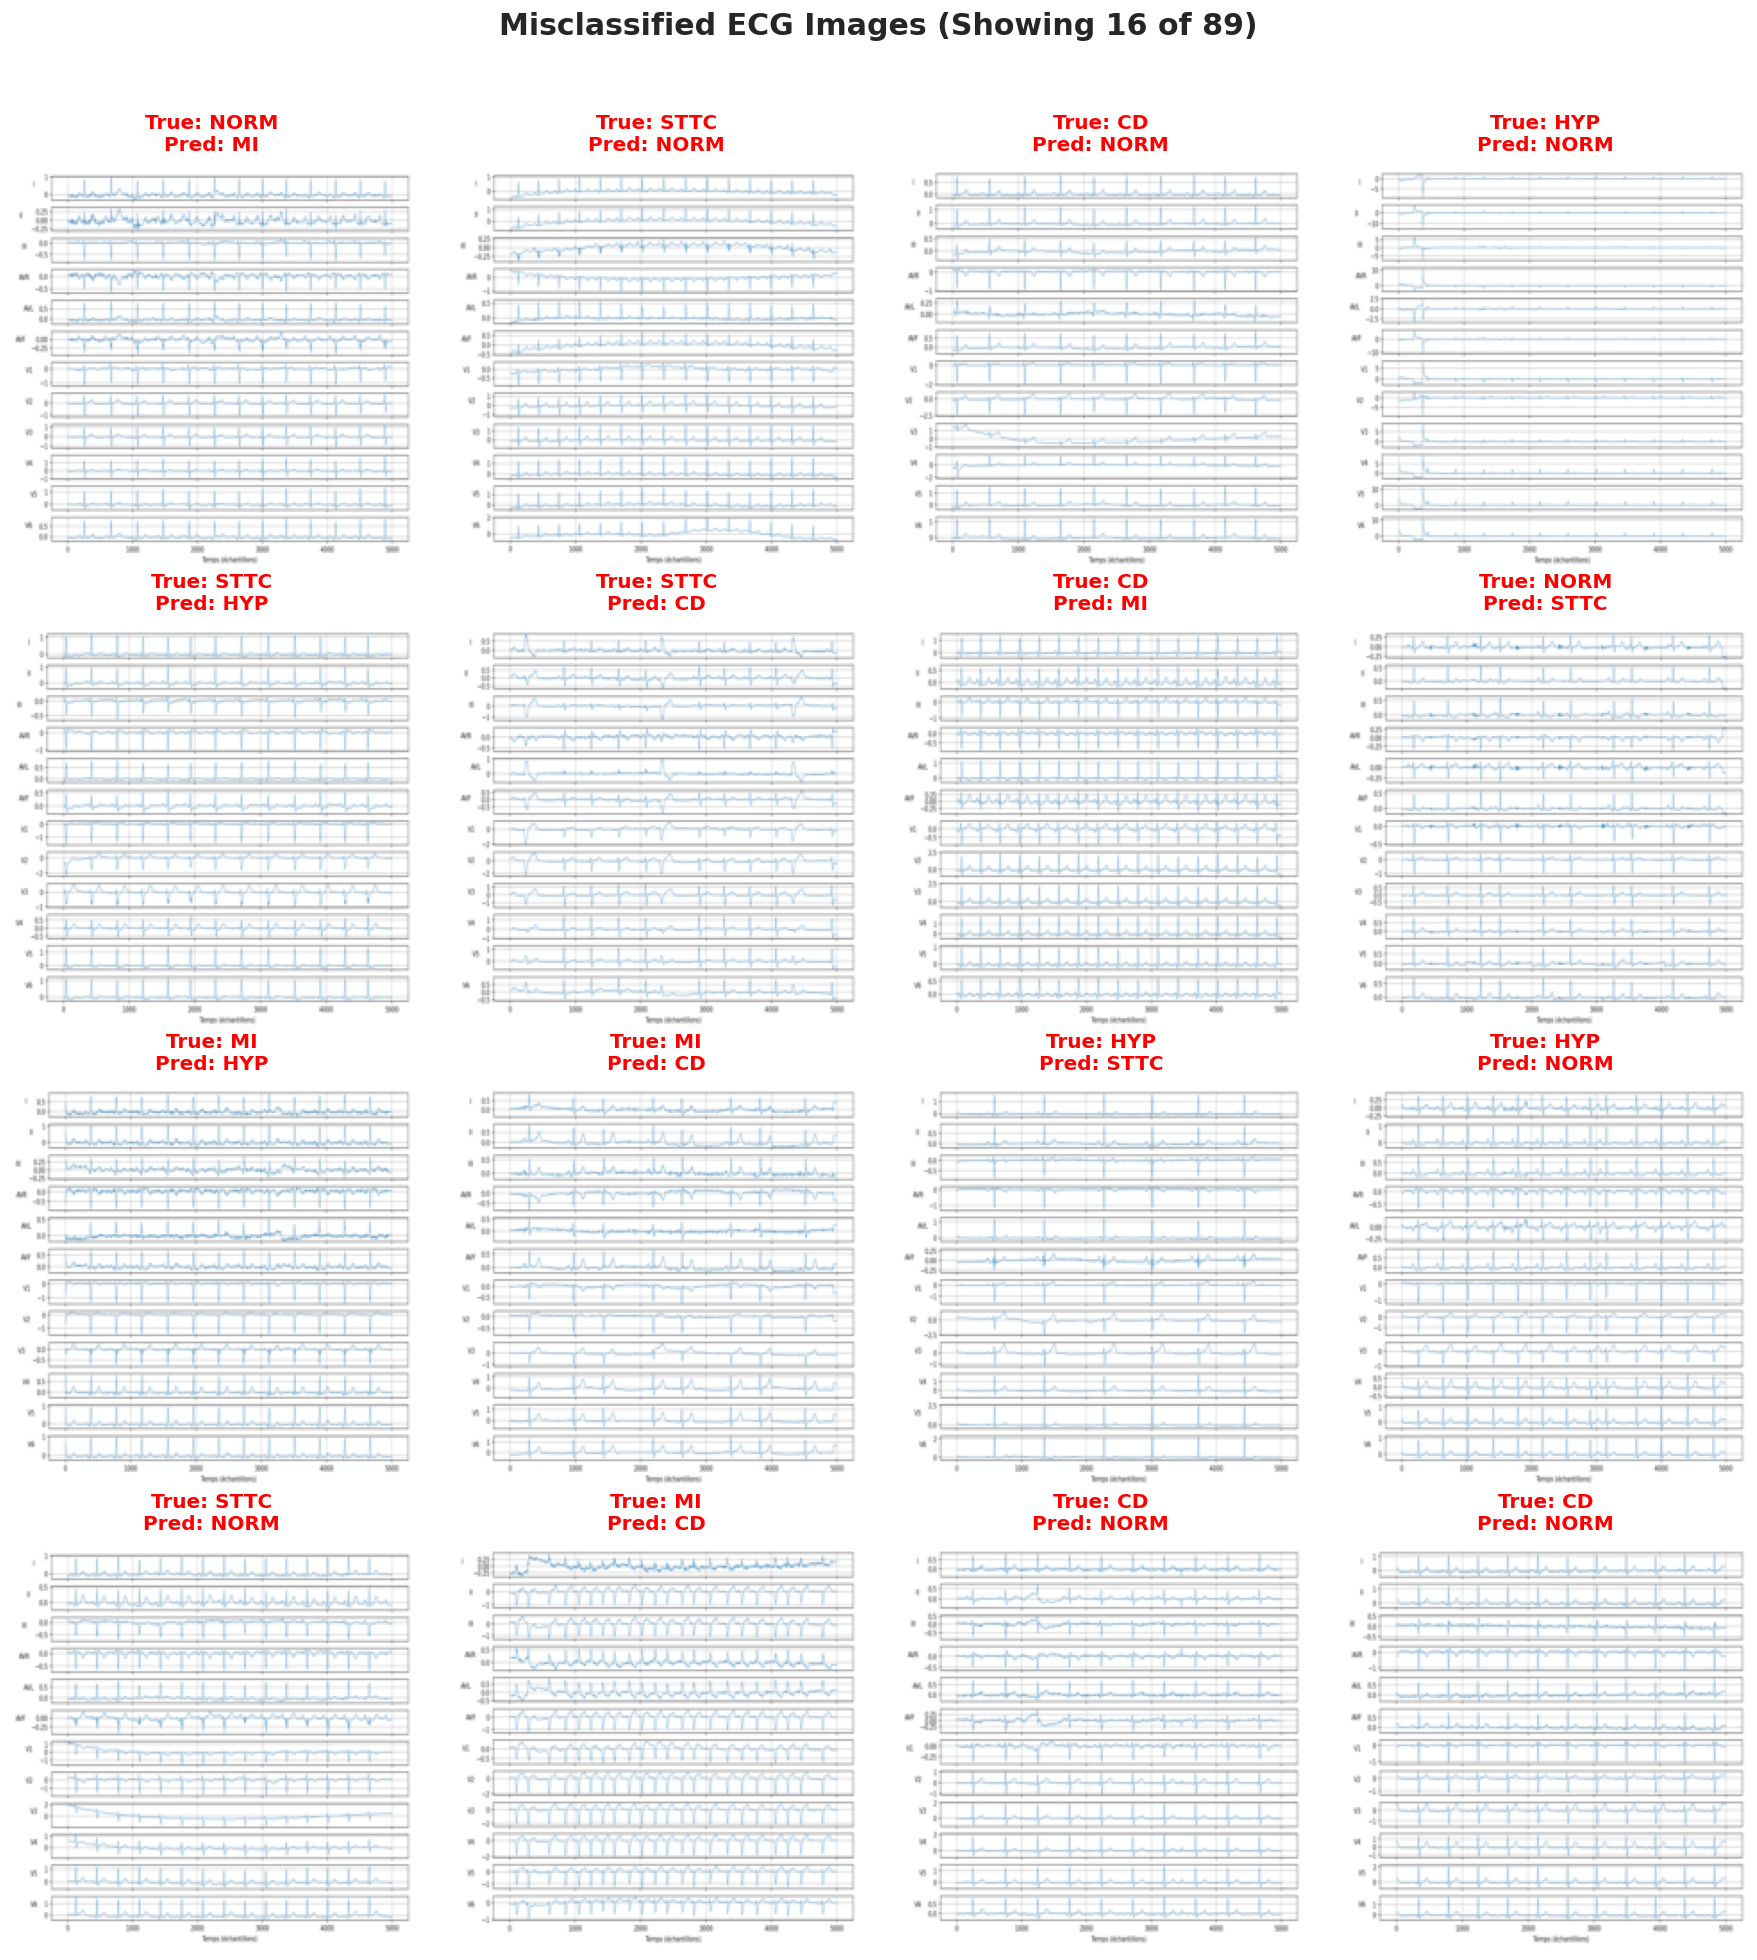

In [26]:
# Find the exact indices where the model's prediction did not match the true label
incorrect_indices = np.where(all_preds != all_labels)[0]

if len(incorrect_indices) == 0:
    print("Incredible! The model got 100% accuracy on the test set. No misclassifications to show.")
else:
    print(f"Total misclassified images in test set: {len(incorrect_indices)}")
    
    # Limit to a maximum of 16 images (4x4 grid) to prevent massive plots
    num_to_show = min(16, len(incorrect_indices))
    
    # Calculate grid rows based on number of images to show
    rows = int(np.ceil(num_to_show / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(15, 4 * rows))
    
    # Flatten axes for easy iteration (in case of multiple rows)
    if rows > 1:
        axes = axes.flatten()
    else:
        # If there's only 1 row, axes might be 1D or a single object; ensure it's iterable
        axes = np.array(axes).flatten()
    
    for i, idx in enumerate(incorrect_indices[:num_to_show]):
        # Retrieve the original image tensor from the test_dataset
        img_tensor, _ = test_dataset[idx]
        
        # Un-normalize the image for human viewing
        img = img_tensor.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Get the text labels for the classes
        true_class = class_names[all_labels[idx]]
        pred_class = class_names[all_preds[idx]]
        
        # Display the image
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_class}\nPred: {pred_class}", color="red", fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
    # Hide any unused subplots (if num_to_show is not a multiple of 4)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle(f"Misclassified ECG Images (Showing {num_to_show} of {len(incorrect_indices)})", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

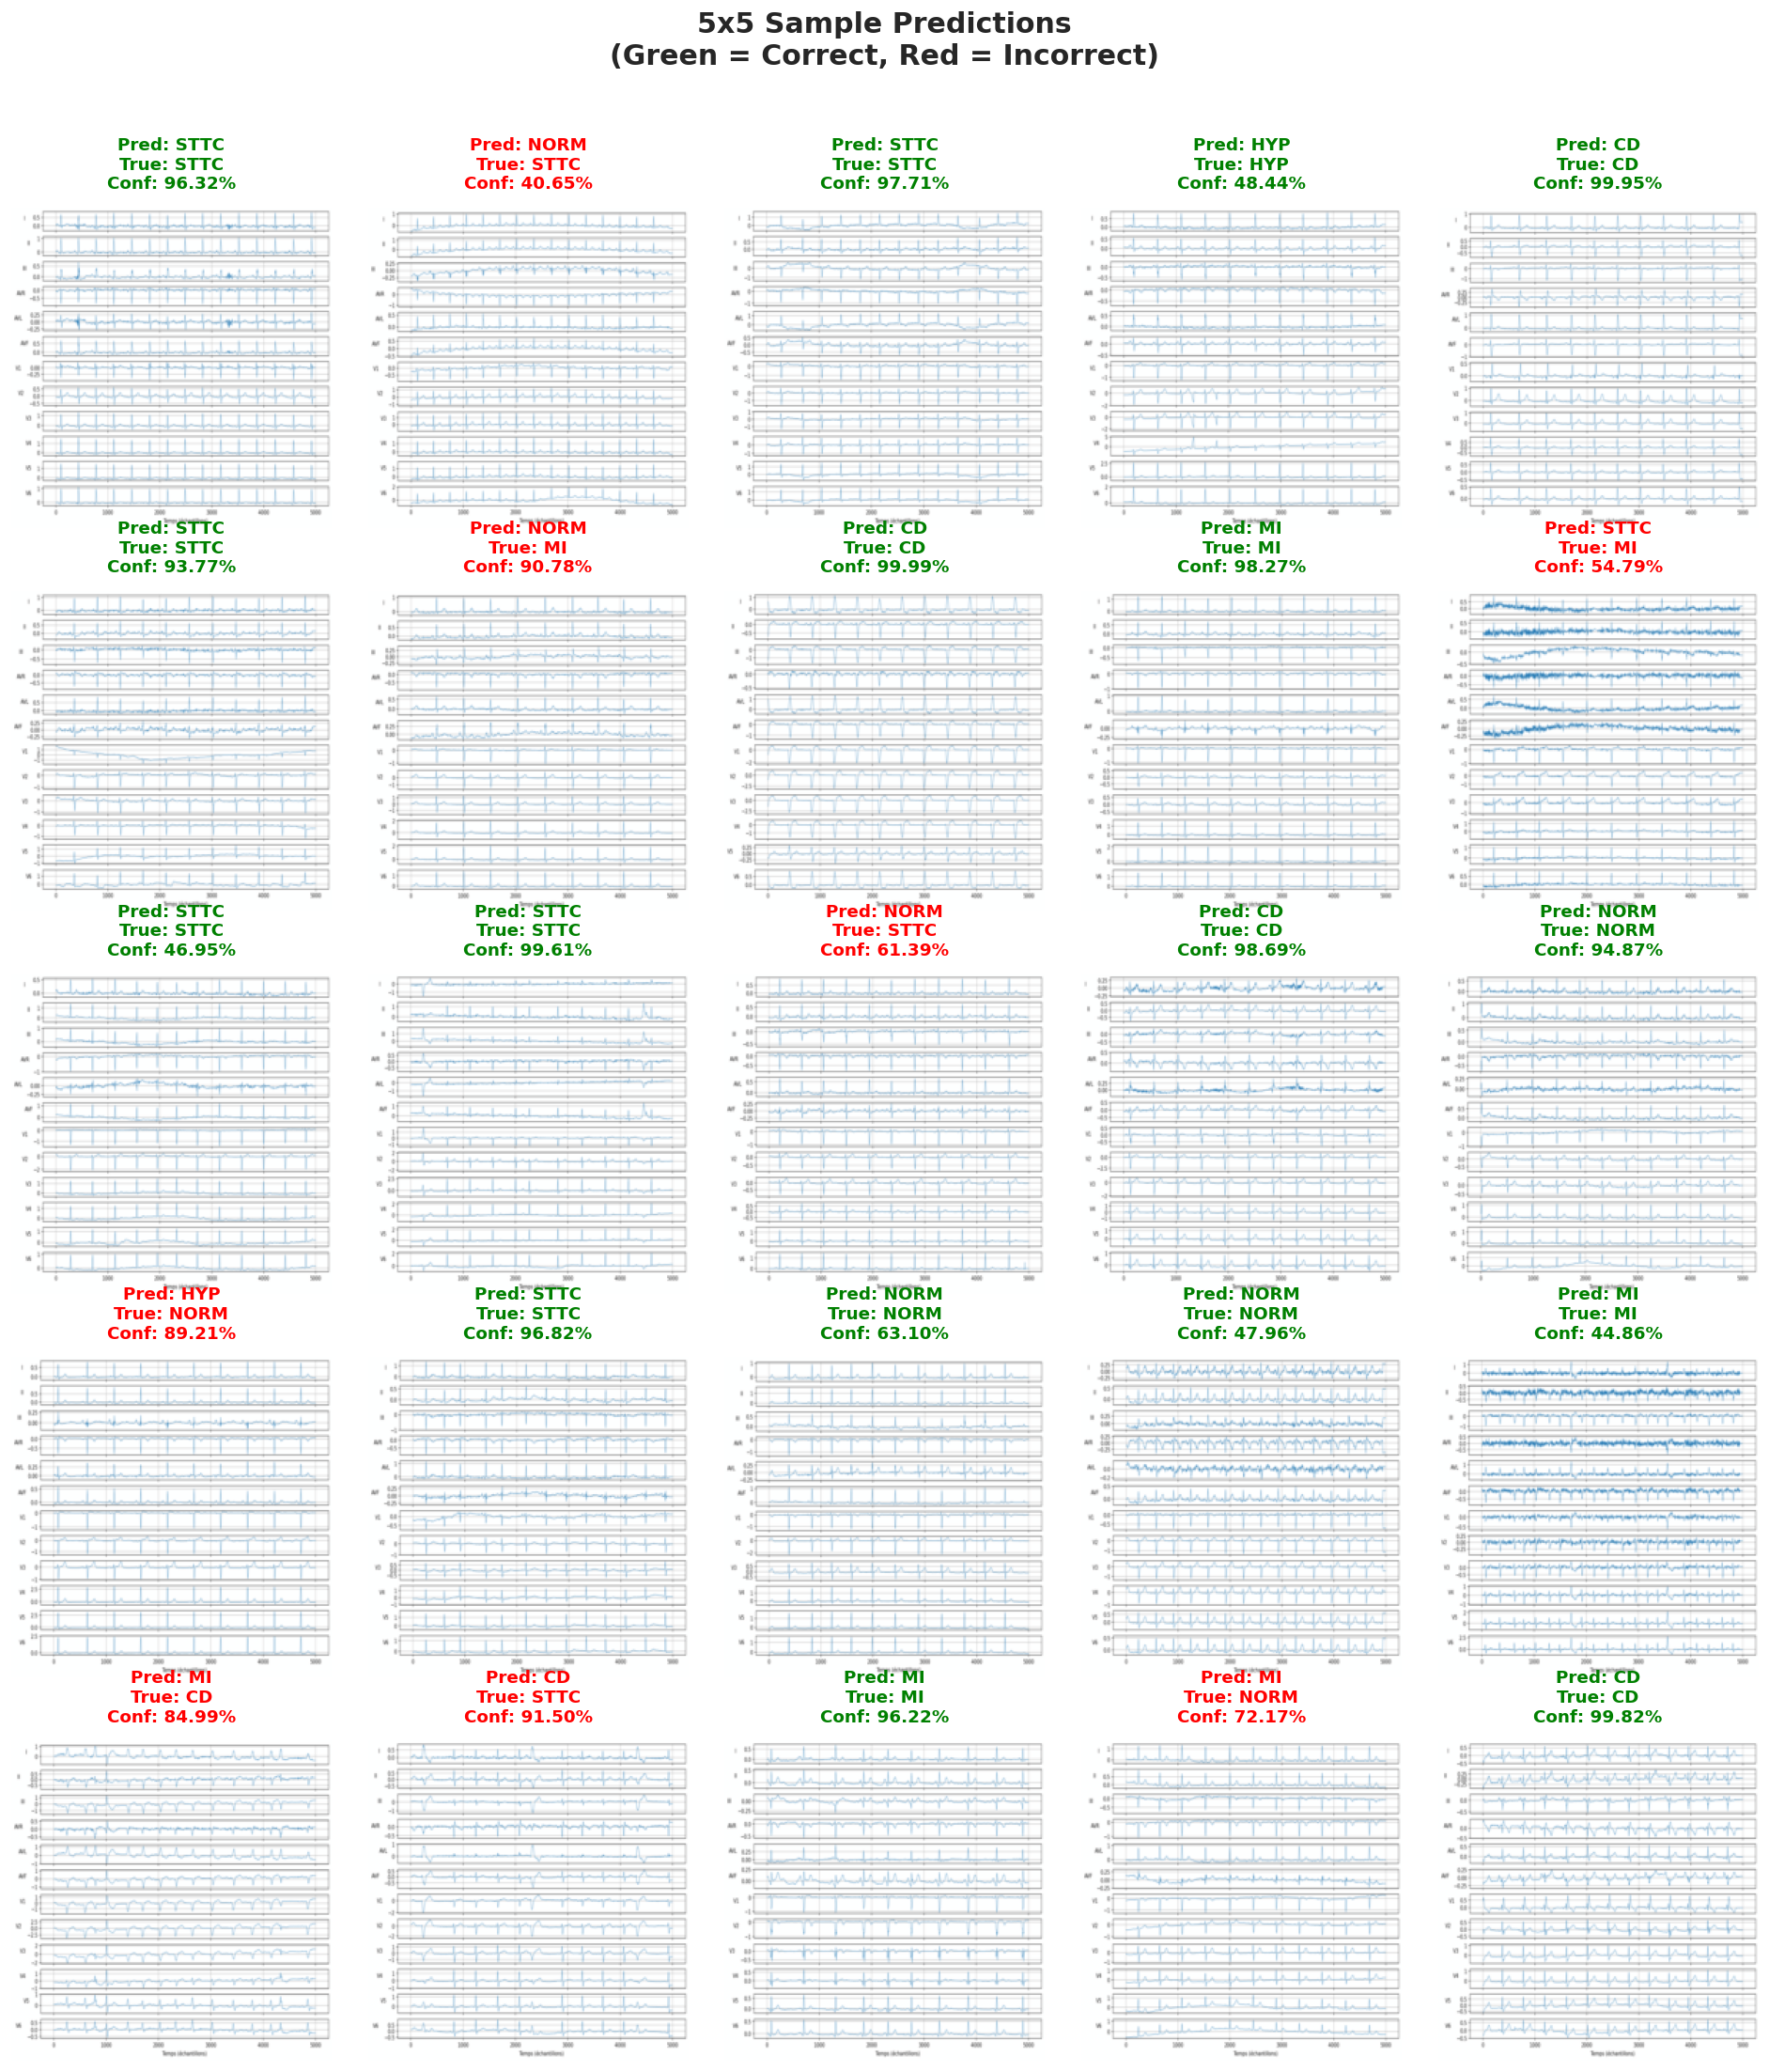

In [27]:
# We want a 5x5 grid, so 25 images total
num_images = 25

# Select 25 random indices from the test set for a varied sample
np.random.seed(42)  # Remove or change this seed if you want different images on every run
sample_indices = np.random.choice(len(test_dataset), num_images, replace=False)

# Set up the plot
fig, axes = plt.subplots(5, 5, figsize=(16, 18))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    # Retrieve the original image tensor from the test_dataset
    img_tensor, _ = test_dataset[idx]
    
    # Un-normalize the image for human viewing
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    # Get labels and the confidence score (max probability)
    true_label_idx = all_labels[idx]
    pred_label_idx = all_preds[idx]
    true_class = class_names[true_label_idx]
    pred_class = class_names[pred_label_idx]
    confidence = np.max(all_probs[idx])
    
    # Determine the text color based on correctness
    if true_label_idx == pred_label_idx:
        title_color = 'green'
    else:
        title_color = 'red'
        
    # Display the image and format the title
    axes[i].imshow(img)
    title_text = f"Pred: {pred_class}\nTrue: {true_class}\nConf: {confidence:.2%}"
    axes[i].set_title(title_text, color=title_color, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("5x5 Sample Predictions\n(Green = Correct, Red = Incorrect)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Ensure the model is in evaluation mode
model.eval()

# Define the exact same transformations used during validation/testing
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_ecg(img):
    """
    Takes a PIL Image from Gradio, runs it through the model, 
    and returns a dictionary of class probabilities.
    """
    # 1. Apply transformations and add a batch dimension (B, C, H, W)
    img_tensor = inference_transform(img).unsqueeze(0).to(device)
    
    # 2. Run the forward pass
    with torch.no_grad():
        outputs = model(img_tensor)
        # Apply softmax to get probabilities ranging from 0 to 1
        probabilities = F.softmax(outputs[0], dim=0)
    
    # 3. Map the probabilities to the corresponding class names
    confidences = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
    
    return confidences

# --- Build the Gradio Interface ---
demo = gr.Interface(
    fn=predict_ecg,
    inputs=gr.Image(type="pil", label="Upload ECG Image"),
    outputs=gr.Label(num_top_classes=5, label="Model Predictions"),
    title="Minimal ECG Classification (5 Classes)",
    description=(
        "Upload an ECG image to classify it into one of 5 categories: "
        "**CD, HYP, MI, NORM, or STTC**.\n\n"
        "The model will return the exact confidence score for each class."
    ),
    allow_flagging="never"
)

# Launch the interface
# share=True creates a temporary public URL you can share with others!
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://62e5cbe9d89920f07f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
